In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


class Logistic_Regression():
    def __init__(self, learning_rate, no_of_iterations):
        self.learning_rate = learning_rate
        self.no_of_iterations = no_of_iterations

    def fit(self, X, Y):
        self.m, self.n = X.shape
        self.w = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.Y = Y

        for i in range(self.no_of_iterations):
            self.update_weights()

    def update_weights(self):
        Y_prediction = self.sigmoid(self.X.dot(self.w) + self.b)

        dw = (1 / self.m) * np.dot(self.X.T, (Y_prediction - self.Y))
        db = (1 / self.m) * np.sum(Y_prediction - self.Y)

        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def predict_proba(self, X):
        return self.sigmoid(X.dot(self.w) + self.b)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

In [2]:
iris = load_iris()

X = iris.data[:, 2:4]
y = iris.target

mask = y != 2
X = X[mask]
y = y[mask]

df = pd.DataFrame({
    'petal_length_cm': X[:, 0],
    'petal_width_cm': X[:, 1],
    'species': y
})
df['species_name'] = df['species'].map({0: 'Setosa', 1: 'Versicolor'})

df.head()

,petal_length_cm,petal_width_cm,species,species_name
0,1.4,0.2,0,Setosa
1,1.4,0.2,0,Setosa
2,1.3,0.2,0,Setosa
3,1.5,0.2,0,Setosa
4,1.4,0.2,0,Setosa


In [3]:
print('Shape:', df.shape)
print()
print(df.describe().round(2))
print()
print('Class counts:')
print(df['species_name'].value_counts())

Shape: (100, 4)

       petal_length_cm  petal_width_cm  species
count           100.00          100.00    100.0
mean              2.86            0.79      0.5
std               1.45            0.57      0.5
min               1.00            0.10      0.0
25%               1.50            0.20      0.0
50%               2.45            0.80      0.5
75%               4.32            1.30      1.0
max               5.10            1.80      1.0

Class counts:
species_name
Setosa        50
Versicolor    50
Name: count, dtype: int64


## Exploratory Data Analysis

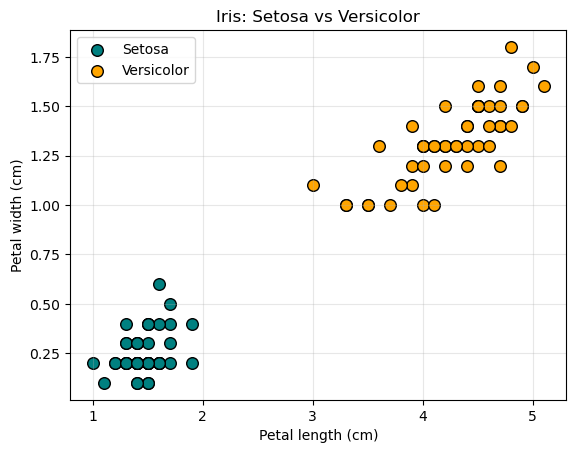

In [4]:
colors = {0: 'teal', 1: 'orange'}
for label, name in [(0, 'Setosa'), (1, 'Versicolor')]:
    subset = df[df['species'] == label]
    plt.scatter(subset['petal_length_cm'], subset['petal_width_cm'],
                color=colors[label], edgecolor='k', s=70, label=name)

plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Iris: Setosa vs Versicolor')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Train / Test Split

In [5]:
X = df[['petal_length_cm', 'petal_width_cm']].values
y = df['species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print('Train size:', len(X_train))
print('Test  size:', len(X_test))

Train size: 70
Test  size: 30


## Feature Scaling (standardisation)

In [6]:
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0)

X_train_norm = (X_train - X_mean) / X_std
X_test_norm  = (X_test  - X_mean) / X_std

print('Train mean:', X_mean.round(3))
print('Train std :', X_std.round(3))

Train mean: [2.861 0.774]
Train std : [1.418 0.555]


## Train the Model (gradient descent)

In [7]:
model = Logistic_Regression(learning_rate=0.1, no_of_iterations=2000)
model.fit(X_train_norm, y_train)

print(f'Weights (normalised space) : {model.w[0]:.3f}, {model.w[1]:.3f}')
print(f'Bias   (normalised space) : {model.b:.3f}')

Weights (normalised space) : 3.289, 3.259
Bias   (normalised space) : 0.493


## Evaluate on the Test Set

In [8]:
y_pred = model.predict(X_test_norm)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy = {accuracy:.3f}')
print()

print('Confusion matrix (rows = actual, columns = predicted):')
print(confusion_matrix(y_test, y_pred))
print()

print('Classification report:')
print(classification_report(y_test, y_pred, target_names=['Setosa', 'Versicolor']))

Accuracy = 1.000

Confusion matrix (rows = actual, columns = predicted):
[[15  0]
 [ 0 15]]

Classification report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        15
  Versicolor       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Visualise the Decision Boundary

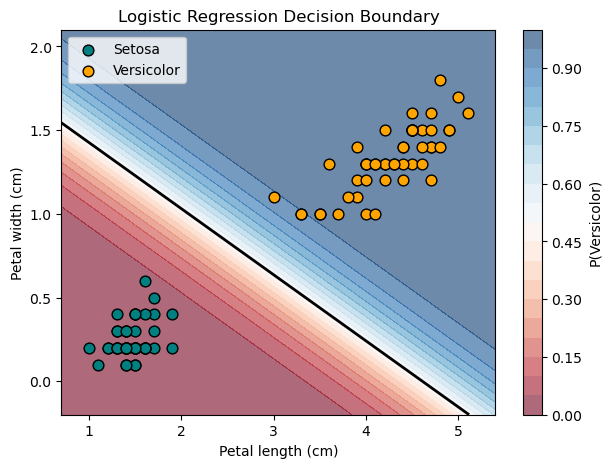

In [9]:
x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_norm = (grid - X_mean) / X_std
probs = model.predict_proba(grid_norm).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, probs, levels=20, cmap='RdBu', alpha=0.6)
plt.colorbar(label='P(Versicolor)')

for label, name in [(0, 'Setosa'), (1, 'Versicolor')]:
    plt.scatter(X[y == label, 0], X[y == label, 1],
                color=colors[label], edgecolor='k', s=60, label=name)

plt.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=2)
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()

## Make a Prediction

In [10]:
new_flower = np.array([[4.5, 1.5]])
new_flower_norm = (new_flower - X_mean) / X_std

p = model.predict_proba(new_flower_norm)[0]
label = model.predict(new_flower_norm)[0]
name = 'Versicolor' if label == 1 else 'Setosa'

print(f'New flower (petal length 4.5 cm, width 1.5 cm):')
print(f'  P(Versicolor) = {p:.3f}')
print(f'  Predicted     = {name}')

New flower (petal length 4.5 cm, width 1.5 cm):
  P(Versicolor) = 1.000
  Predicted     = Versicolor
